# Ejercicio Binning, imputacion, outliers, dummies etc
El siguiente Dataset contiene detalles de 1000 potenciales compradores de bicicletas, realizaremos un análisis exploratorio del mismo, imputando las variables que correspondan.

1. ¿Cuáles de las variables contienen valores nulos?
2. ¿Está Balanceada la variable target 'Purchased Bike'?
3. Imputar los valores nulos de Gender con el valor 'X'.
4. Imputar los valores nulos y outliers de Age con la media.
5. Eliminar los registros con valor nulo en Cars.
6. Generar columnas dummy para las variables Education y Occupation.
7. Definir una estrategia de imputación para las otras variables que corresponda.
8. Finalizar el análisis exploratorio con gráficos del dataset.

In [3]:
import pandas as pd
bike_buyers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/bike_buyers.csv')

In [4]:
bike_buyers.describe(include='all')
#1. filtrar variables con valores nulos
columnas_con_nulos = bike_buyers.columns[bike_buyers.isnull().any()]
print(columnas_con_nulos)
nulos_pct = bike_buyers.isnull().mean() * 100
nulos_pct[nulos_pct > 0].round(2)
print(nulos_pct)

Index(['Marital Status', 'Gender', 'Income', 'Children', 'Home Owner', 'Cars',
       'Age'],
      dtype='str')
ID                  0.0
Marital Status      0.7
Gender              1.1
Income              0.6
Children            0.8
Education           0.0
Occupation          0.0
Home Owner          0.4
Cars                0.9
Commute Distance    0.0
Region              0.0
Age                 0.7
Purchased Bike      0.0
dtype: float64


Purchased Bike
No     51.9
Yes    48.1
Name: proportion, dtype: float64


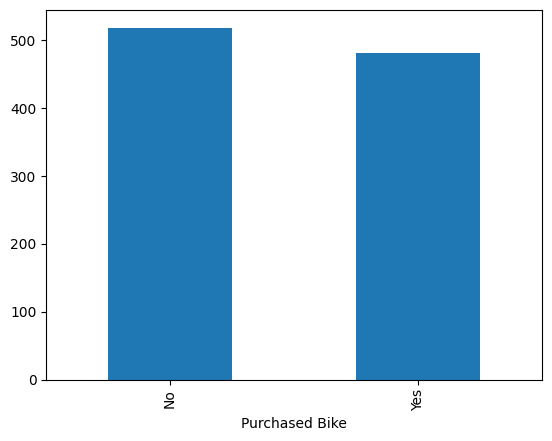

In [5]:
#2 variables balanceadas
bike_buyers['Purchased Bike'].value_counts().plot(kind='bar')
print(bike_buyers['Purchased Bike'].value_counts(normalize=True) * 100)
#Se considera balanceada cuando las clases tienen proporciones similares (cerca del 50/50). Si una clase supera el 60-70% del total, se considera desbalanceada.


In [6]:
#3. Imputar los valores nulos de Gender con el valor 'X'.
bike_buyers['Gender'] = bike_buyers['Gender'].fillna('X')
bike_buyers['Gender'].isnull().sum()  # debe dar 0
bike_buyers['Gender'].value_counts()  # debe aparecer 'X'


Gender
Male      500
Female    489
X          11
Name: count, dtype: int64

count    993.000000
mean      44.139980
std       12.338209
min      -28.000000
25%       35.000000
50%       43.000000
75%       52.000000
max      160.000000
Name: Age, dtype: float64
58     -8.0
371   -28.0
Name: Age, dtype: float64
121    160.0
Name: Age, dtype: float64
Media limpia: 44.1
9.5
77.5


np.int64(0)

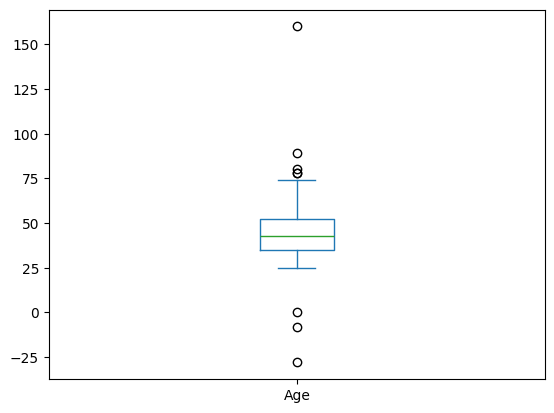

In [7]:
#4. Imputar los valores nulos y outliers de Age con la media.
# 1. Análisis exploratorio de Age
print(bike_buyers['Age'].describe())
bike_buyers['Age'].plot(kind='box')

# 1.2 Ver los valores problemáticos
print(bike_buyers[bike_buyers['Age'] < 0]['Age'])
print(bike_buyers[bike_buyers['Age'] > 120]['Age'])

# 2. Calcular la media SOLO con valores válidos (antes de imputar nada)
media_age = bike_buyers[(bike_buyers['Age'] >= 0) & (bike_buyers['Age'] <= 120)]['Age'].mean()
print(f"Media limpia: {media_age:.1f}")
# 3. Reemplazar errores de dominio
bike_buyers.loc[bike_buyers['Age'] < 0, 'Age'] = media_age
bike_buyers.loc[bike_buyers['Age'] > 120, 'Age'] = media_age
# 4. Detectar y reemplazar outliers estadísticos con IQR
Q1 = bike_buyers['Age'].quantile(0.25)
Q3 = bike_buyers['Age'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(limite_inferior)
print(limite_superior)
bike_buyers.loc[bike_buyers['Age'] < limite_inferior, 'Age'] = media_age
bike_buyers.loc[bike_buyers['Age'] > limite_superior, 'Age'] = media_age
# 5. Imputar nulos usando la media de anios
bike_buyers['Age'] = bike_buyers['Age'].fillna(media_age)
bike_buyers['Age'].isnull().sum()  # debe dar 0


In [8]:
#5. Eliminar los registros con valor nulo en Cars.
# Ver cuántos nulos hay antes
print(bike_buyers['Cars'].isnull().sum())

# Eliminar filas con nulo en Cars
bike_buyers = bike_buyers.dropna(subset=['Cars'])

# Verificar
print(bike_buyers['Cars'].isnull().sum())  # debe dar 0
print(bike_buyers.shape)                   # ver cuántas filas quedaron

9
0
(991, 13)


In [9]:
#6. Generar columnas dummy para las variables Education y Occupation.
# Generar dummies
dummies_education = pd.get_dummies(bike_buyers['Education'], prefix='Education')
dummies_occupation = pd.get_dummies(bike_buyers['Occupation'], prefix='Occupation')

# Agregar al DataFrame y eliminar las originales
bike_buyers = pd.concat([bike_buyers, dummies_education, dummies_occupation], axis=1)
#bike_buyers = bike_buyers.drop(columns=['Education', 'Occupation'])

# Verificar
bike_buyers.head()



,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,...,Education_Bachelors,Education_Graduate Degree,Education_High School,Education_Partial College,Education_Partial High School,Occupation_Clerical,Occupation_Management,Occupation_Manual,Occupation_Professional,Occupation_Skilled Manual
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,...,True,False,False,False,False,False,False,False,False,True
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,...,False,False,False,True,False,True,False,False,False,False
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,...,False,False,False,True,False,False,False,False,True,False
3,24381,Single,X,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,...,True,False,False,False,False,False,False,False,True,False
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,...,True,False,False,False,False,True,False,False,False,False


In [10]:
#7. Definir una estrategia de imputación para las otras variables que corresponda.
# tratamiento de nulos
columnas_con_nulos = bike_buyers.columns[bike_buyers.isnull().any()]
print(bike_buyers.isnull().mean() * 100)
print(columnas_con_nulos)
# defenimos un default para martial status = Single, children = 0, Media en income, Home Owner = No
bike_buyers['Marital Status'] = bike_buyers['Marital Status'].fillna('Single')
bike_buyers['Children'] = bike_buyers['Children'].fillna(0)
media_income = bike_buyers['Income'].mean()
bike_buyers['Income'] = bike_buyers['Income'].fillna(media_income)
bike_buyers['Home Owner'] = bike_buyers['Home Owner'].fillna('No')

# Verificar que no queden nulos
bike_buyers.isnull().sum()[bike_buyers.isnull().sum() > 0]

# Ver distribución para decidir media vs mediana
bike_buyers['Income'].skew()  # si abs(skew) > 1 → mediana, sino → media

ID                               0.000000
Marital Status                   0.706357
Gender                           0.000000
Income                           0.605449
Children                         0.807265
Education                        0.000000
Occupation                       0.000000
Home Owner                       0.403633
Cars                             0.000000
Commute Distance                 0.000000
Region                           0.000000
Age                              0.000000
Purchased Bike                   0.000000
Education_Bachelors              0.000000
Education_Graduate Degree        0.000000
Education_High School            0.000000
Education_Partial College        0.000000
Education_Partial High School    0.000000
Occupation_Clerical              0.000000
Occupation_Management            0.000000
Occupation_Manual                0.000000
Occupation_Professional          0.000000
Occupation_Skilled Manual        0.000000
dtype: float64
Index(['Marital Sta

np.float64(0.7275300361446209)

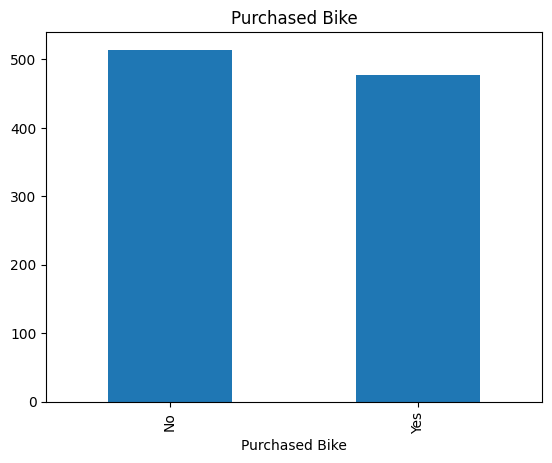

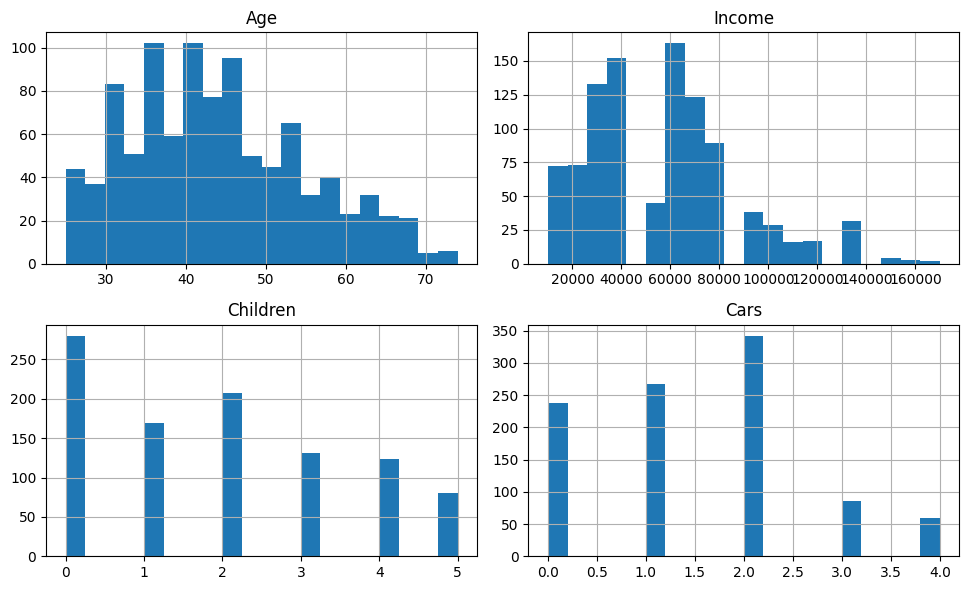

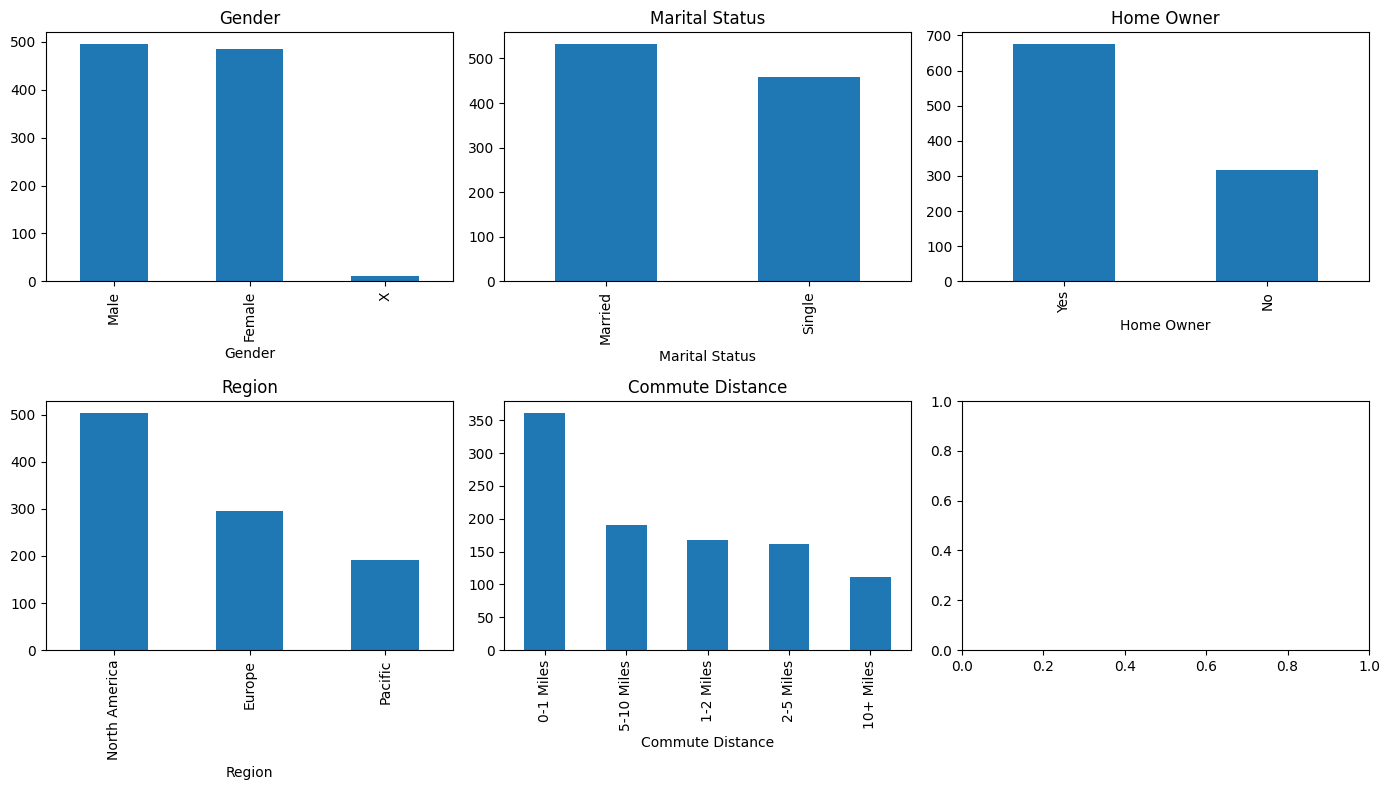

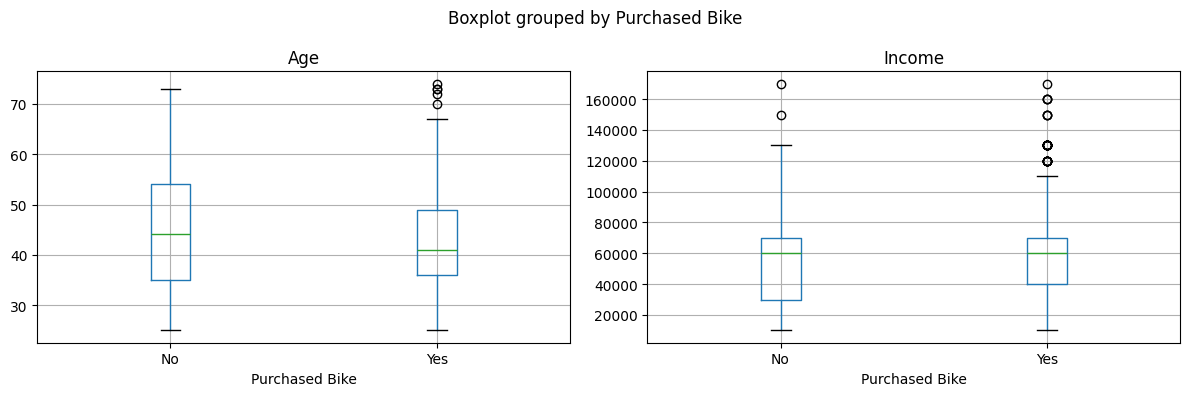

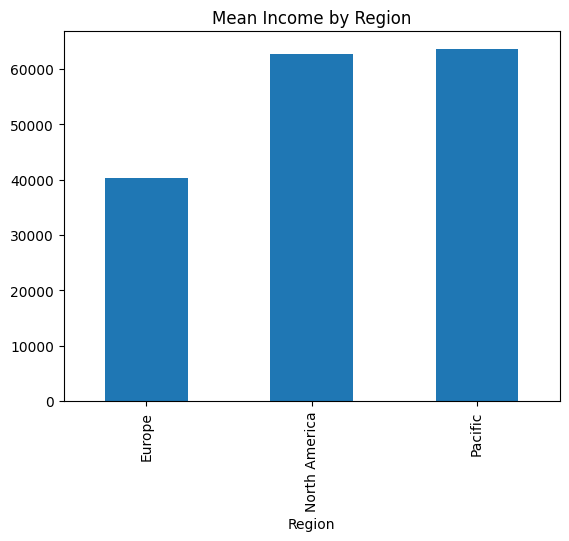

In [11]:
import matplotlib.pyplot as plt

# 1. Distribución de la variable target
bike_buyers['Purchased Bike'].value_counts().plot(kind='bar', title='Purchased Bike')
plt.show()

# 2. Distribución de variables numéricas
numericas = ['Age', 'Income', 'Children', 'Cars']
bike_buyers[numericas].hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

# 3. Variables categóricas
categoricas = ['Gender', 'Marital Status', 'Home Owner', 'Region', 'Commute Distance']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    bike_buyers[col].value_counts().plot(kind='bar', ax=axes[i], title=col)

plt.tight_layout()
plt.show()

# 4. Relación entre Age/Income y la variable target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bike_buyers.boxplot(column='Age', by='Purchased Bike', ax=axes[0])
bike_buyers.boxplot(column='Income', by='Purchased Bike', ax=axes[1])
plt.tight_layout()
plt.show()

# 5. Correlación entre variables numéricas
bike_buyers[numericas].corr().style.background_gradient(cmap='coolwarm')

# 6. grafico que muestra mean income por region
bike_buyers.groupby('Region')['Income'].mean().plot(kind='bar', title='Mean Income by Region')
plt.show()  